<a href="https://colab.research.google.com/github/GiannaReyes/eel4660-spring2026-python-basics-python-basics-1/blob/main/Duck_Detection_Gianna_Reyes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/112.6 GB disk)


# Change path to your yaml file

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")

# Train the model
results = model.train(data="/content/drive/MyDrive/duck detection.v2i.yolov11/data.yaml", epochs=100, imgsz=640)

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/duck detection.v2i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list containing mAP50-95 for each category

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 28.6±10.0 MB/s, size: 50.7 KB)
val: Scanning /content/drive/MyDrive/duck detection.v2i.yolov11/valid/labels.cache... 3 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.8it/s 0.1s
                   all          3         19          1      0.907      0.946      0.537
Speed: 1.3ms preprocess, 23.9ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/val


array([    0.53713])

# Change path to your test images folder

In [ ]:
model.predict('/content/drive/MyDrive/duck detection.v2i.yolov11/test/images', save=True)


image 1/1 /content/drive/MyDrive/duck detection.v2i.yolov11/test/images/27_jpg.rf.9ce26b5c00d7cc47e4e39c0825dbda25.jpg: 480x640 (no detections), 53.7ms
Speed: 1.7ms preprocess, 53.7ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Duck'}
 obb: None
 orig_img: array([[[194, 205, 213],
         [190, 201, 209],
         [176, 187, 195],
         ...,
         [214, 217, 221],
         [190, 193, 197],
         [171, 174, 178]],
 
        [[195, 206, 214],
         [192, 203, 211],
         [177, 188, 196],
         ...,
         [109, 112, 116],
         [ 90,  93,  97],
         [ 78,  81,  85]],
 
        [[197, 208, 216],
         [193, 204, 212],
         [179, 190, 198],
         ...,
         [ 86,  89,  93],
         [ 92,  95,  99],
         [ 95,  98, 102]],
 
        ...,
 
        [[ 20, 226, 251],
         [ 20, 226, 251],
         [ 19, 225, 250],
         ...,
         [ 68,  71,  76],
         [ 67,  70,  75],
         [ 66,  69,  74]],
 
        [[ 19, 225, 250],
         [ 18, 224, 249],
         [ 18, 224, 249],
         ...,
         [ 65,  68, 

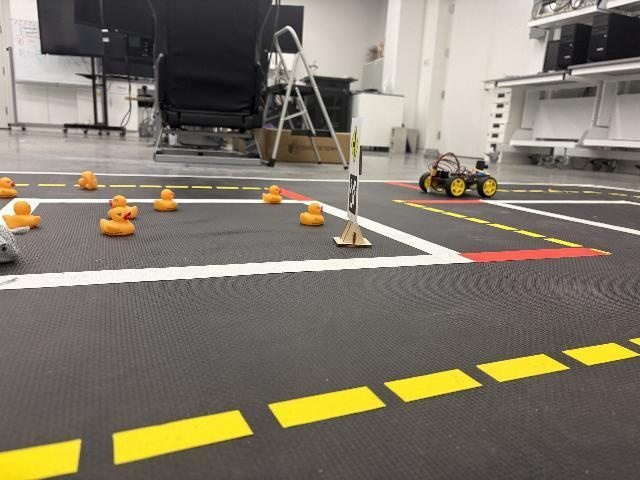

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/predict/*.jpg') + glob.glob('/content/runs/detect/predict/*.png'):
    display(Image(filename=image_path))

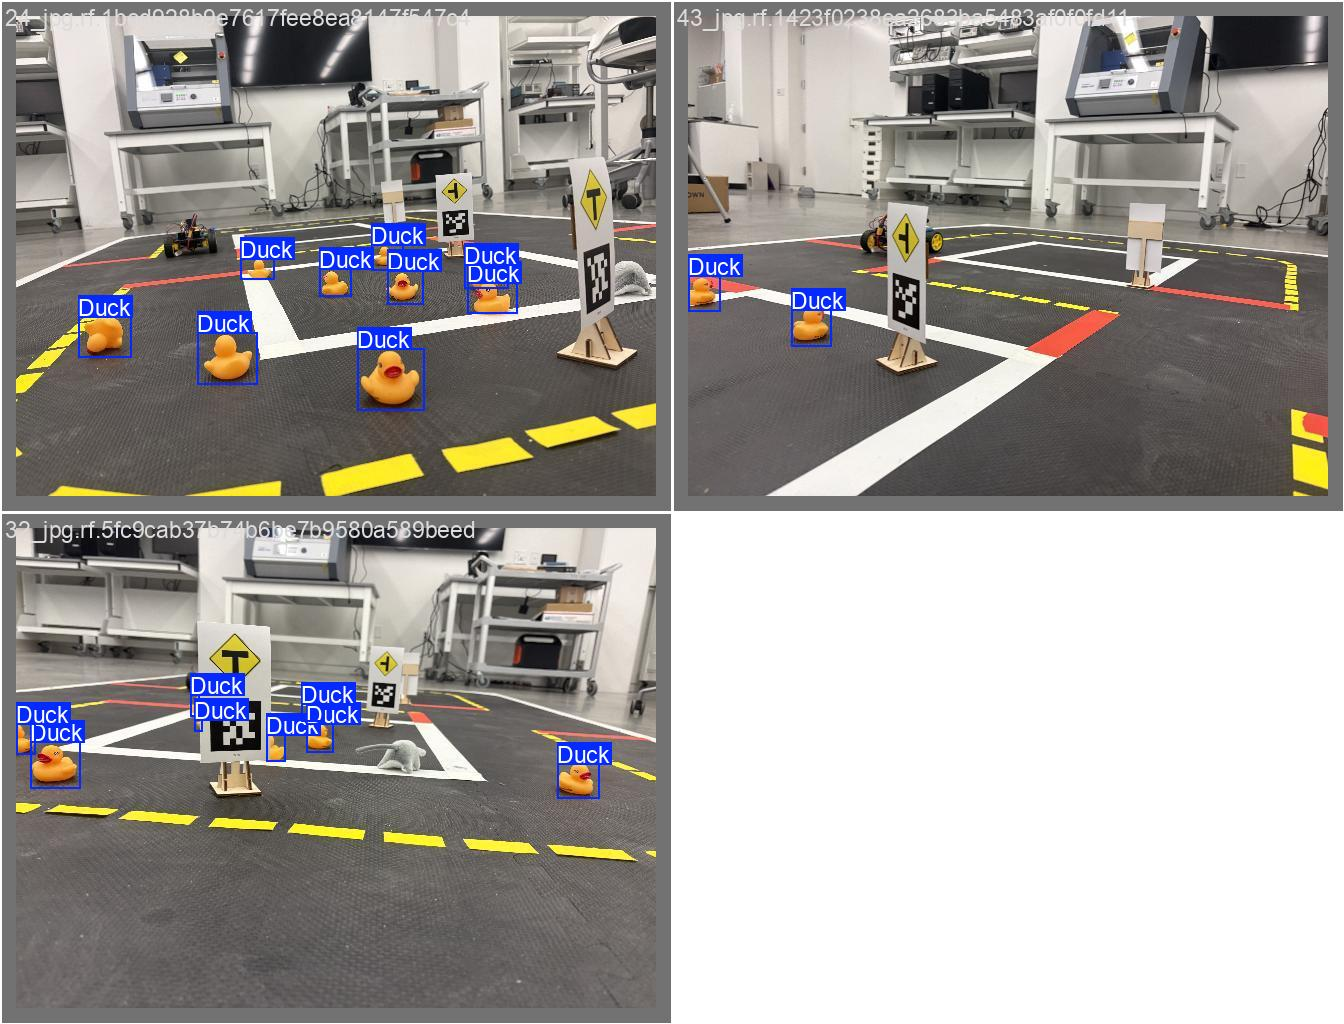

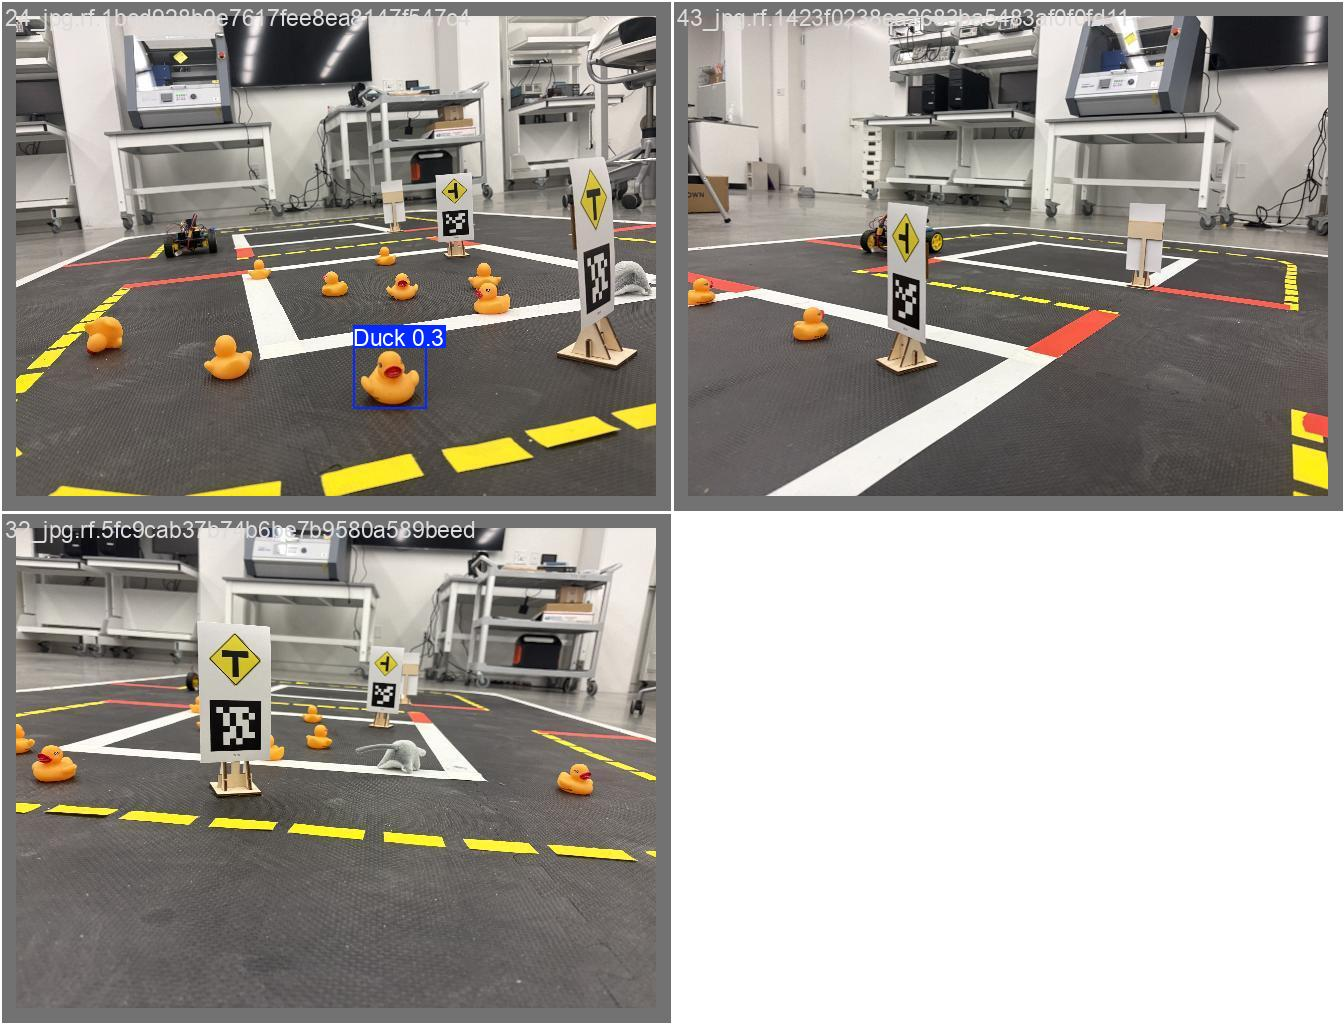

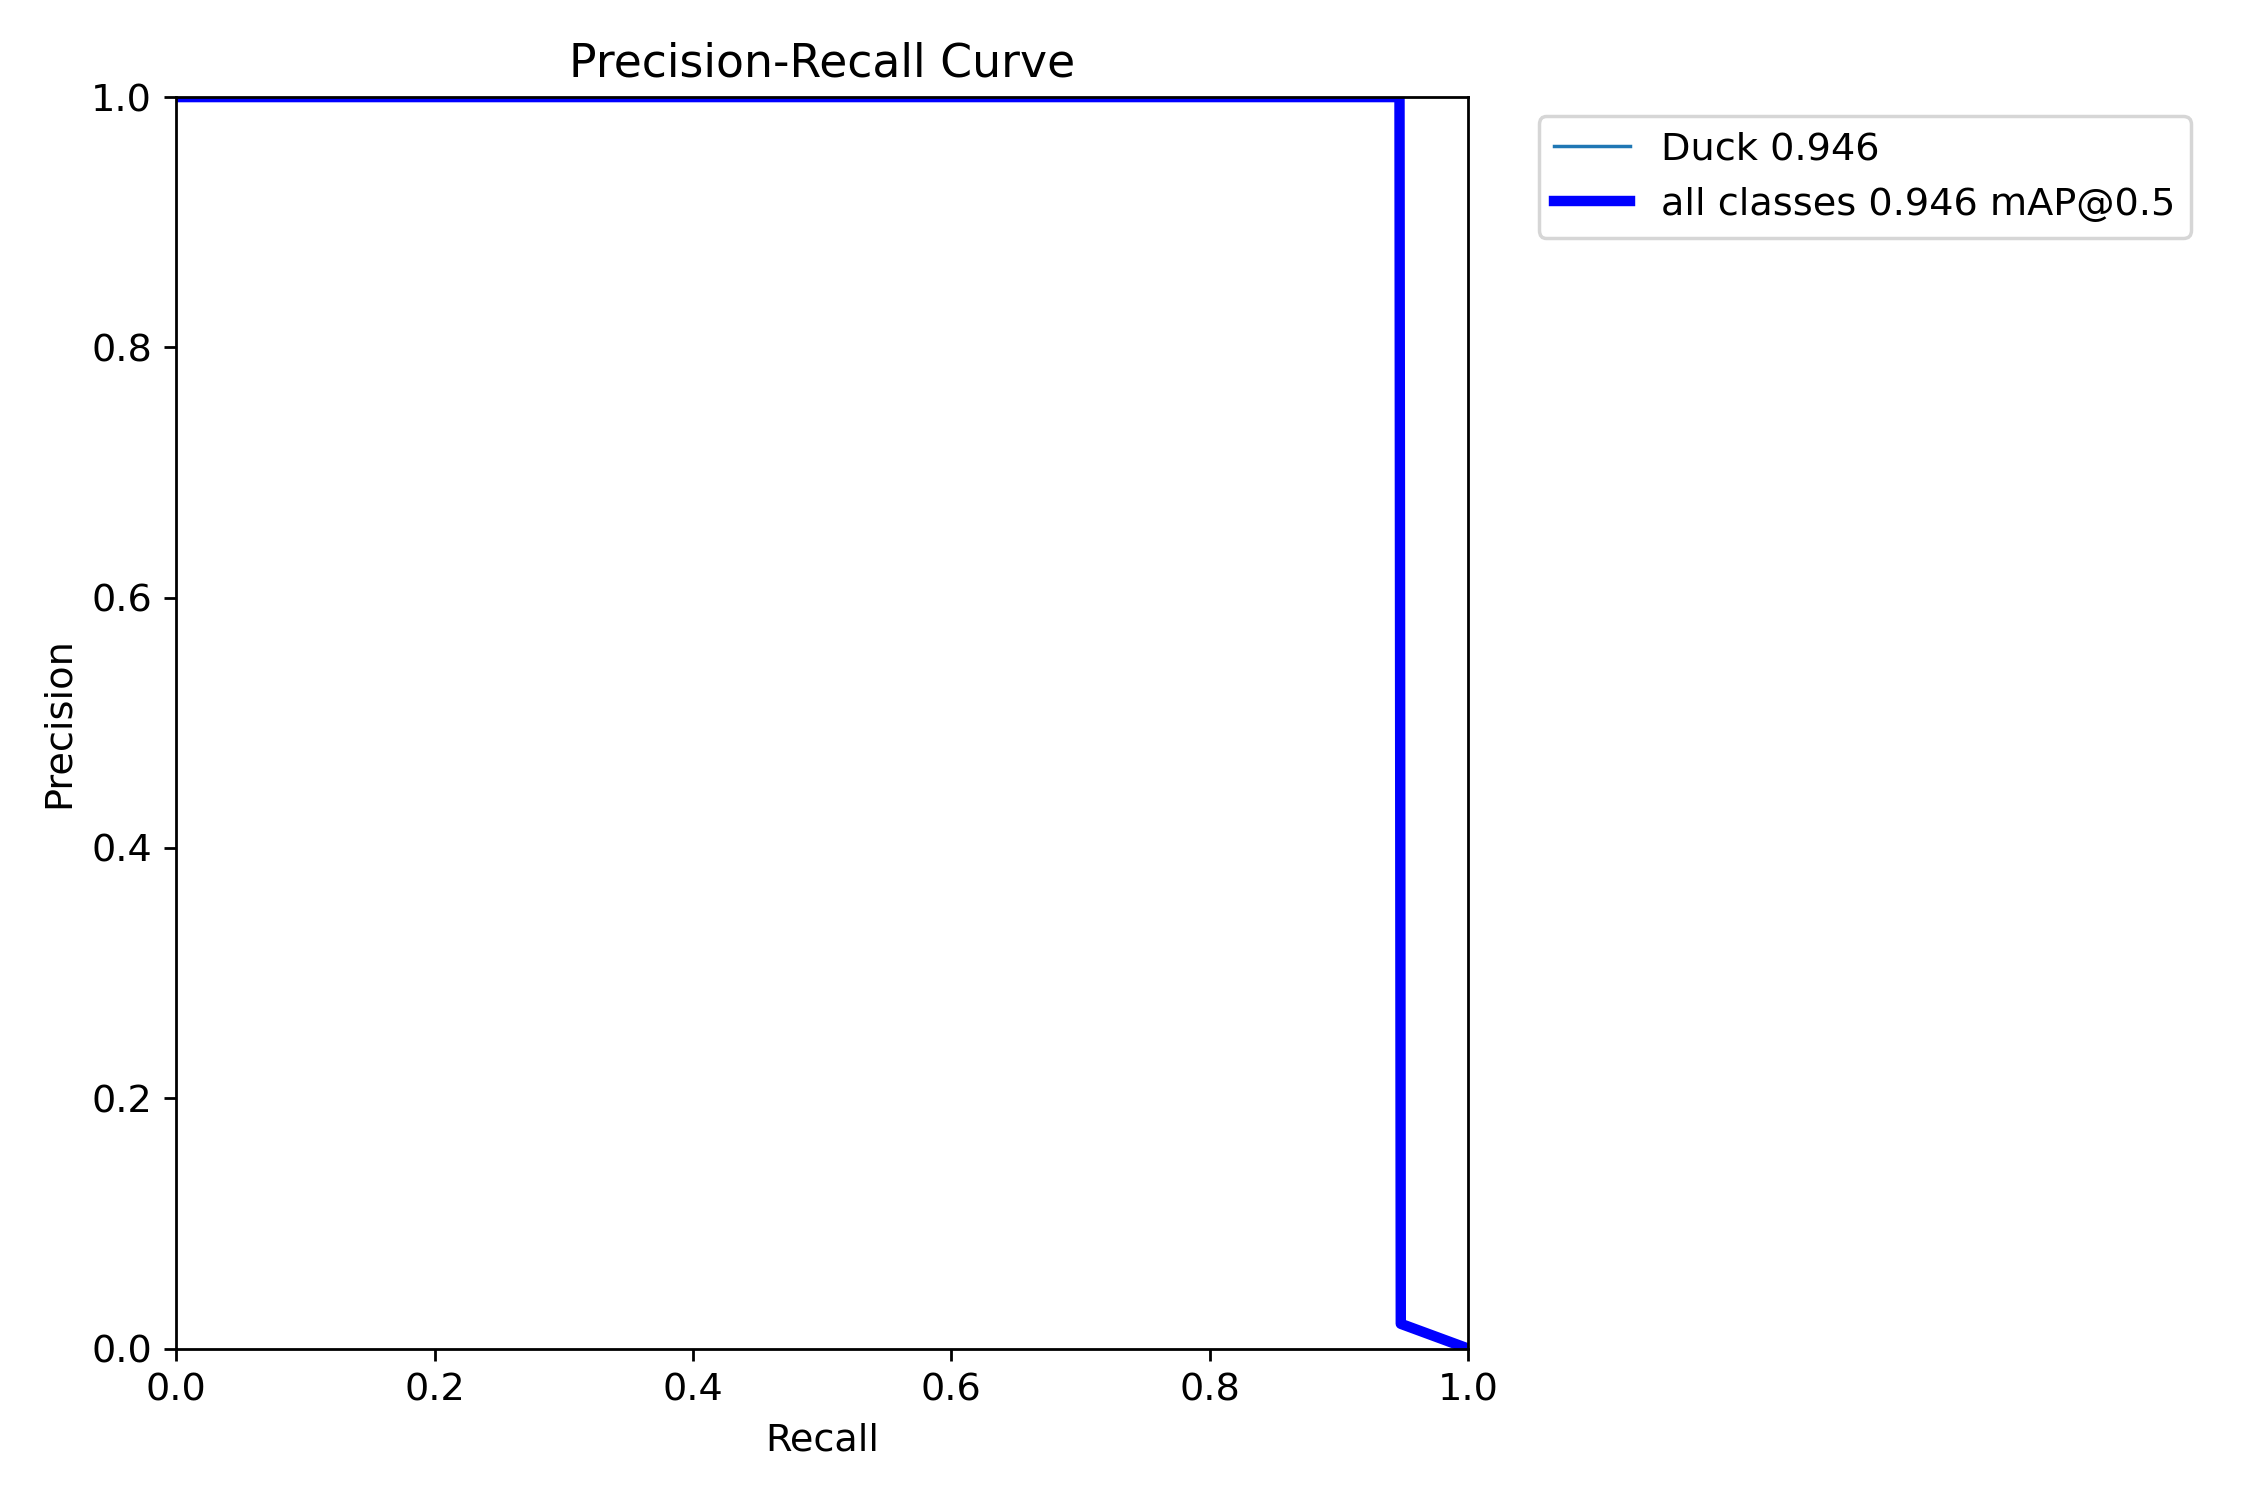

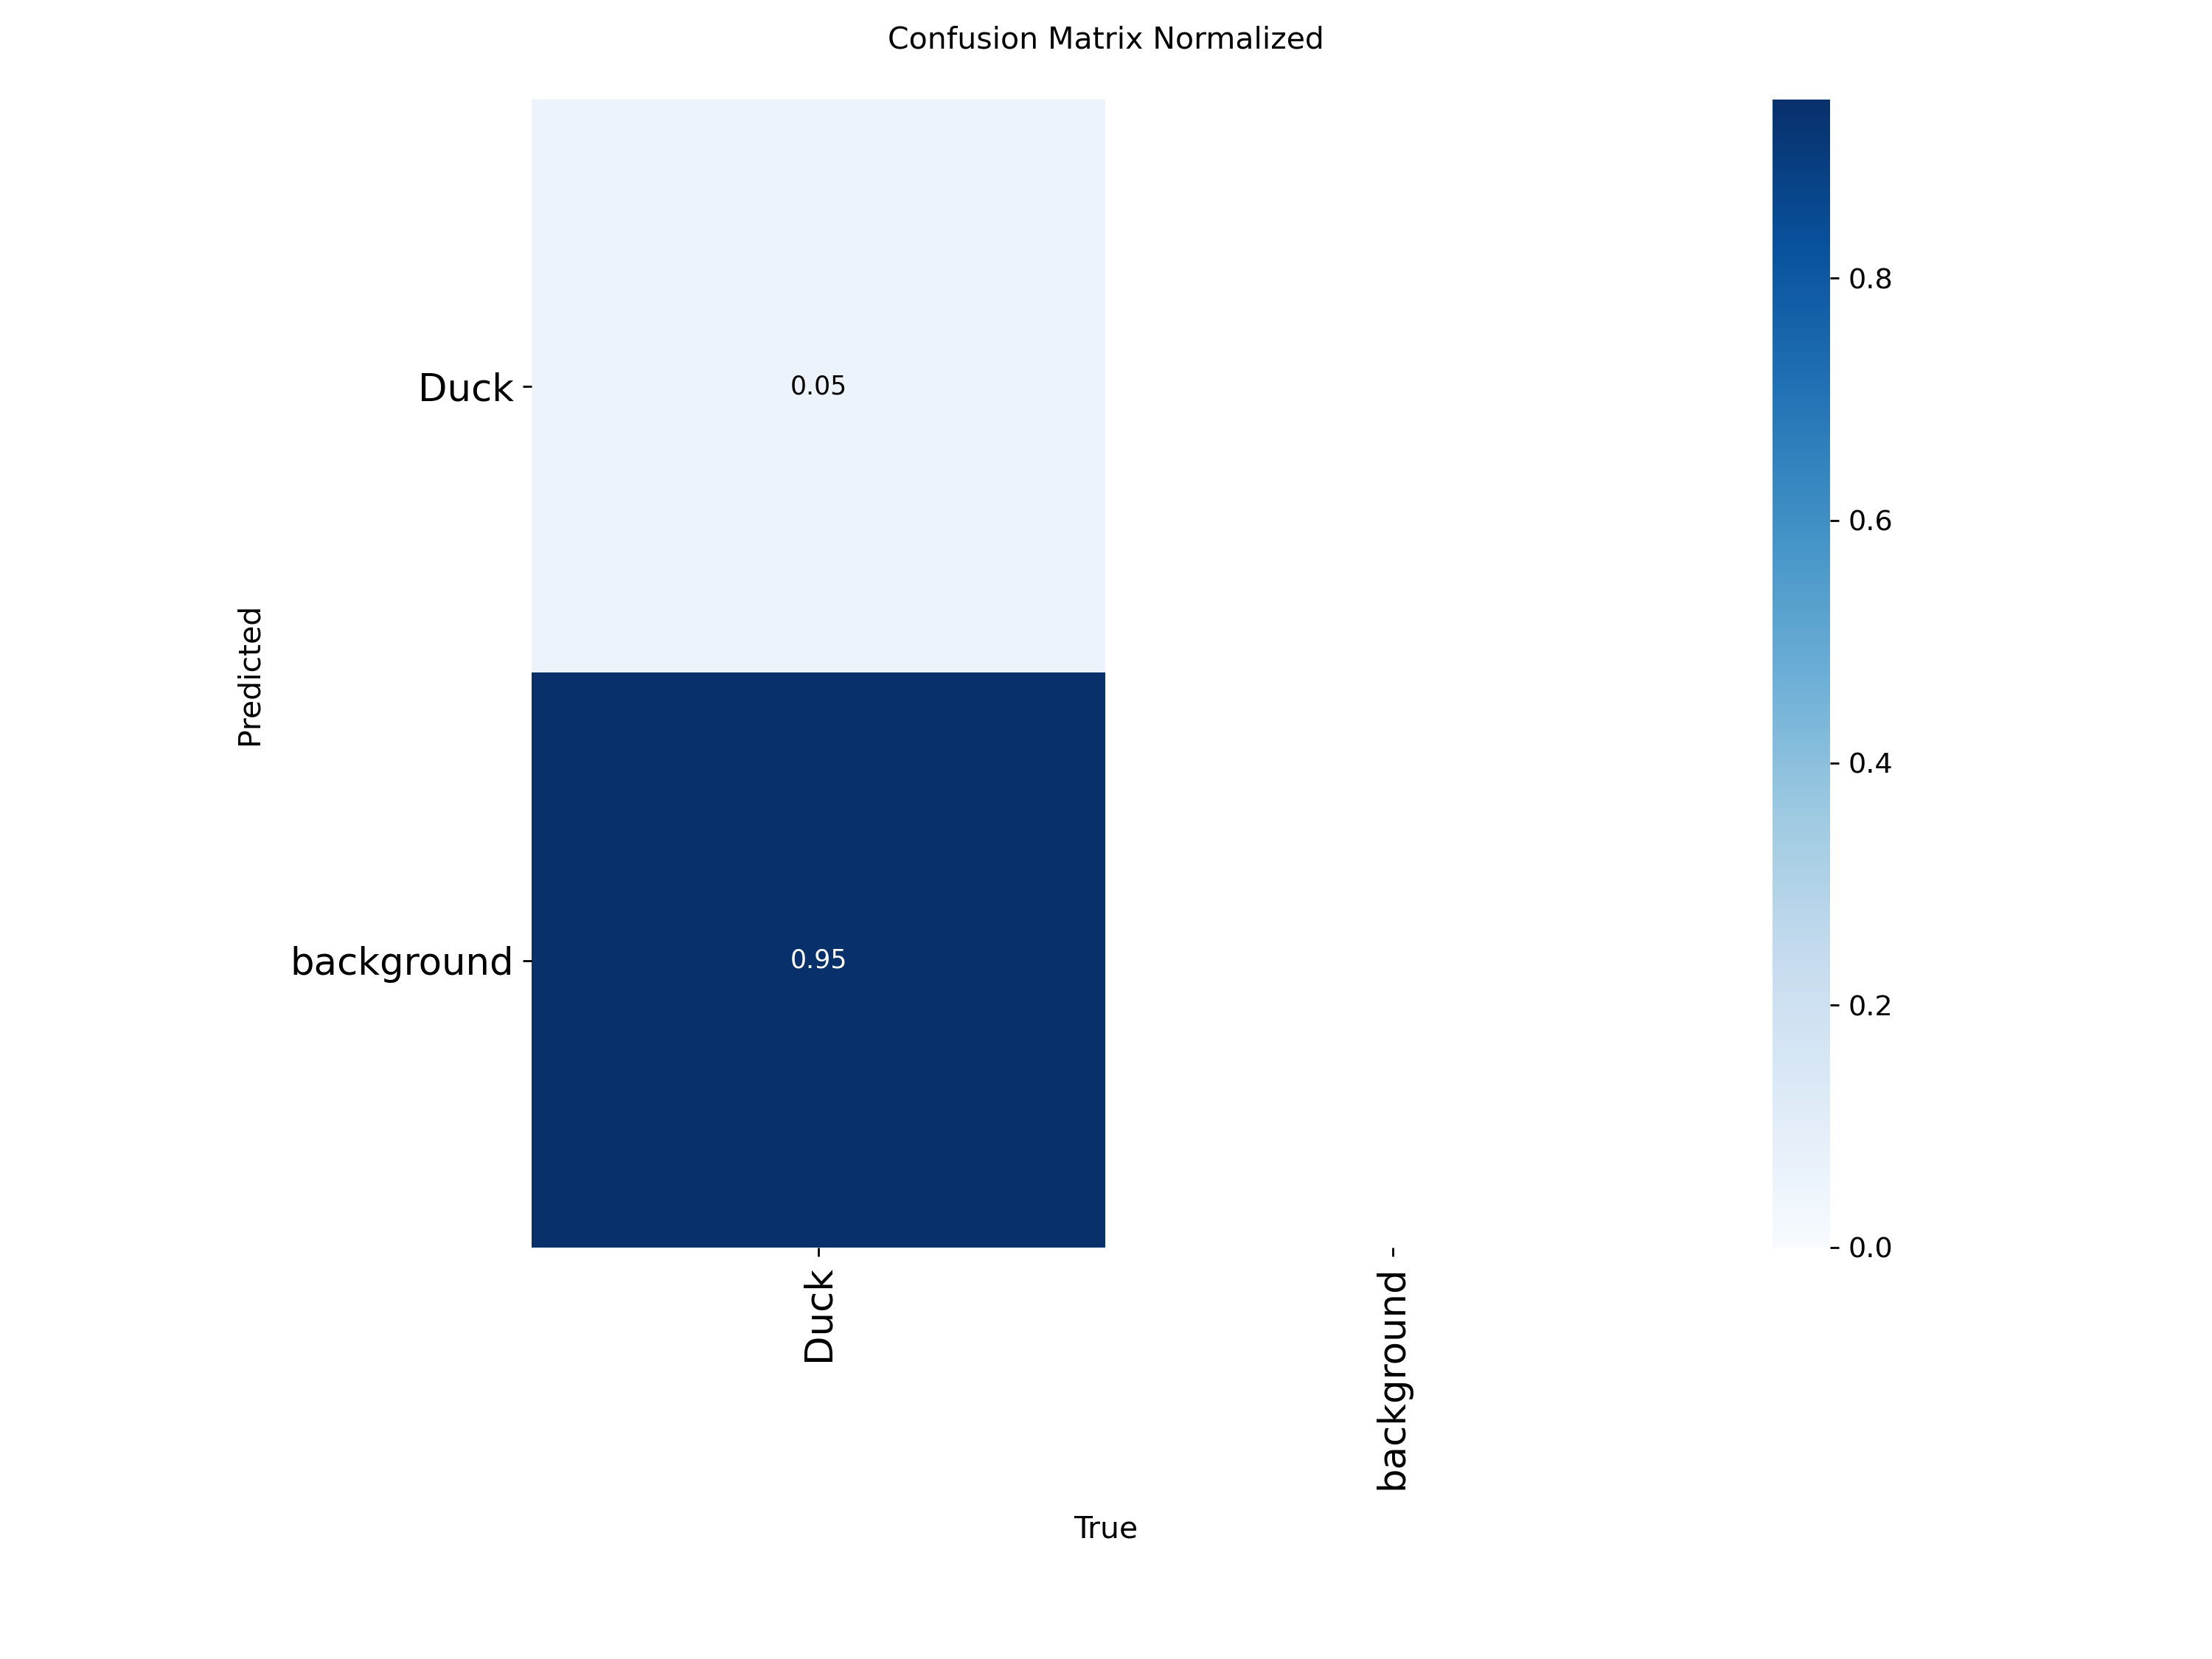

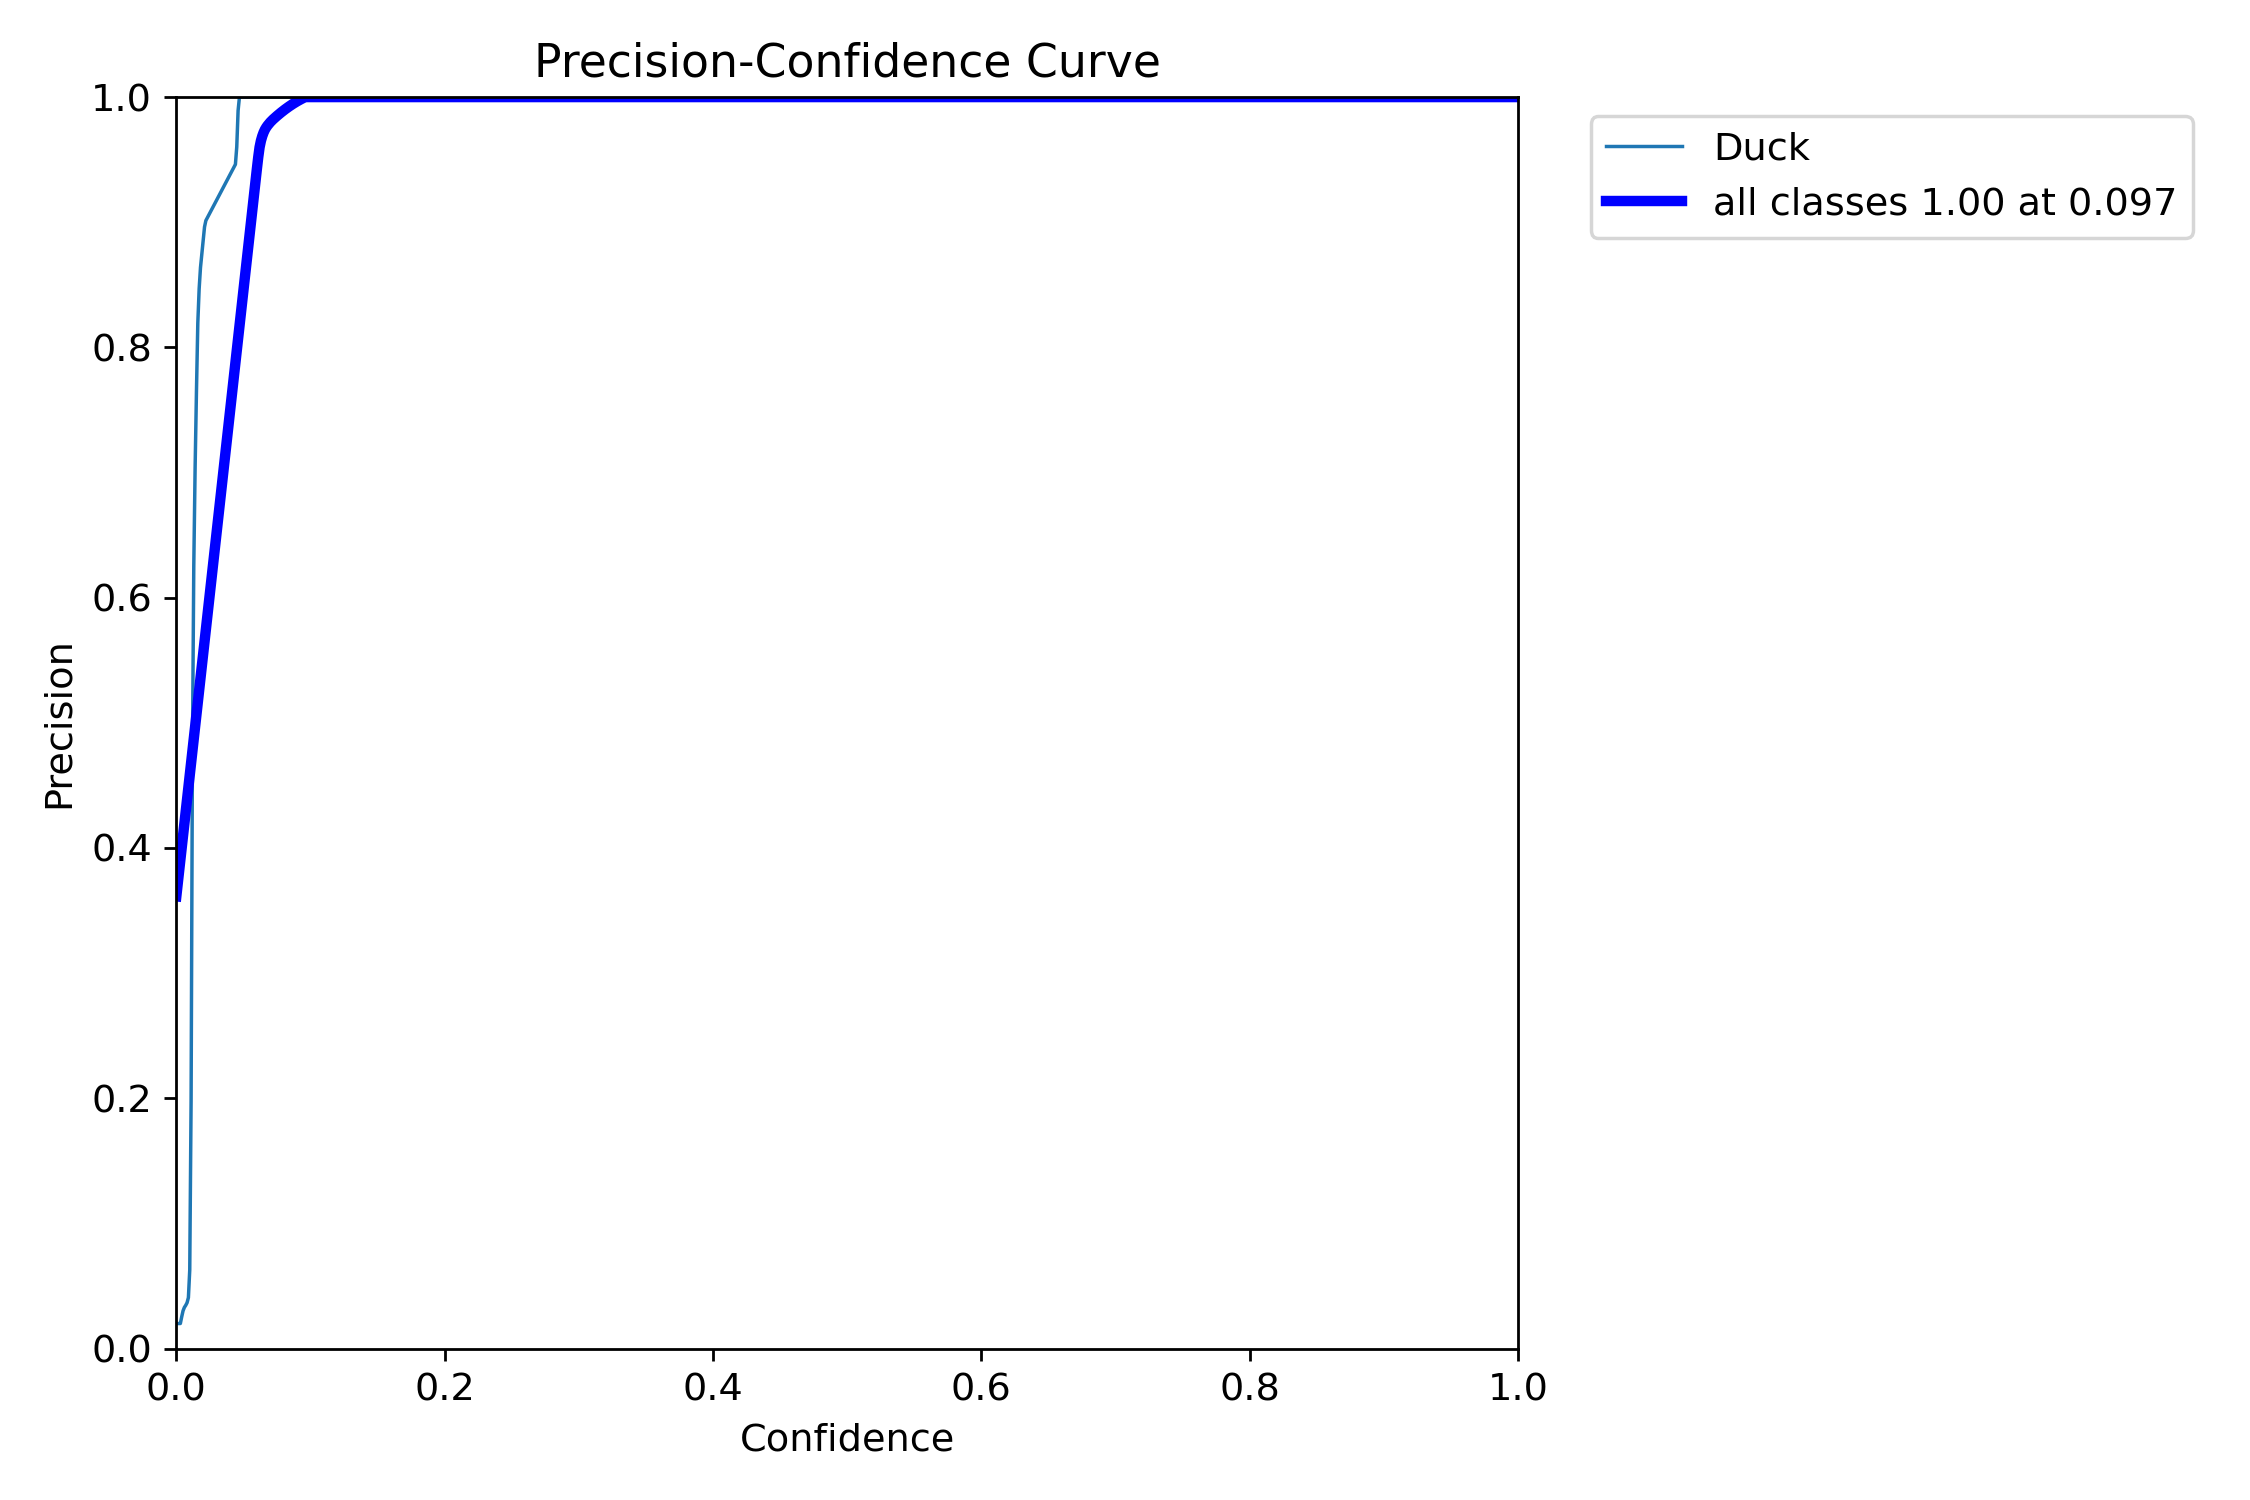

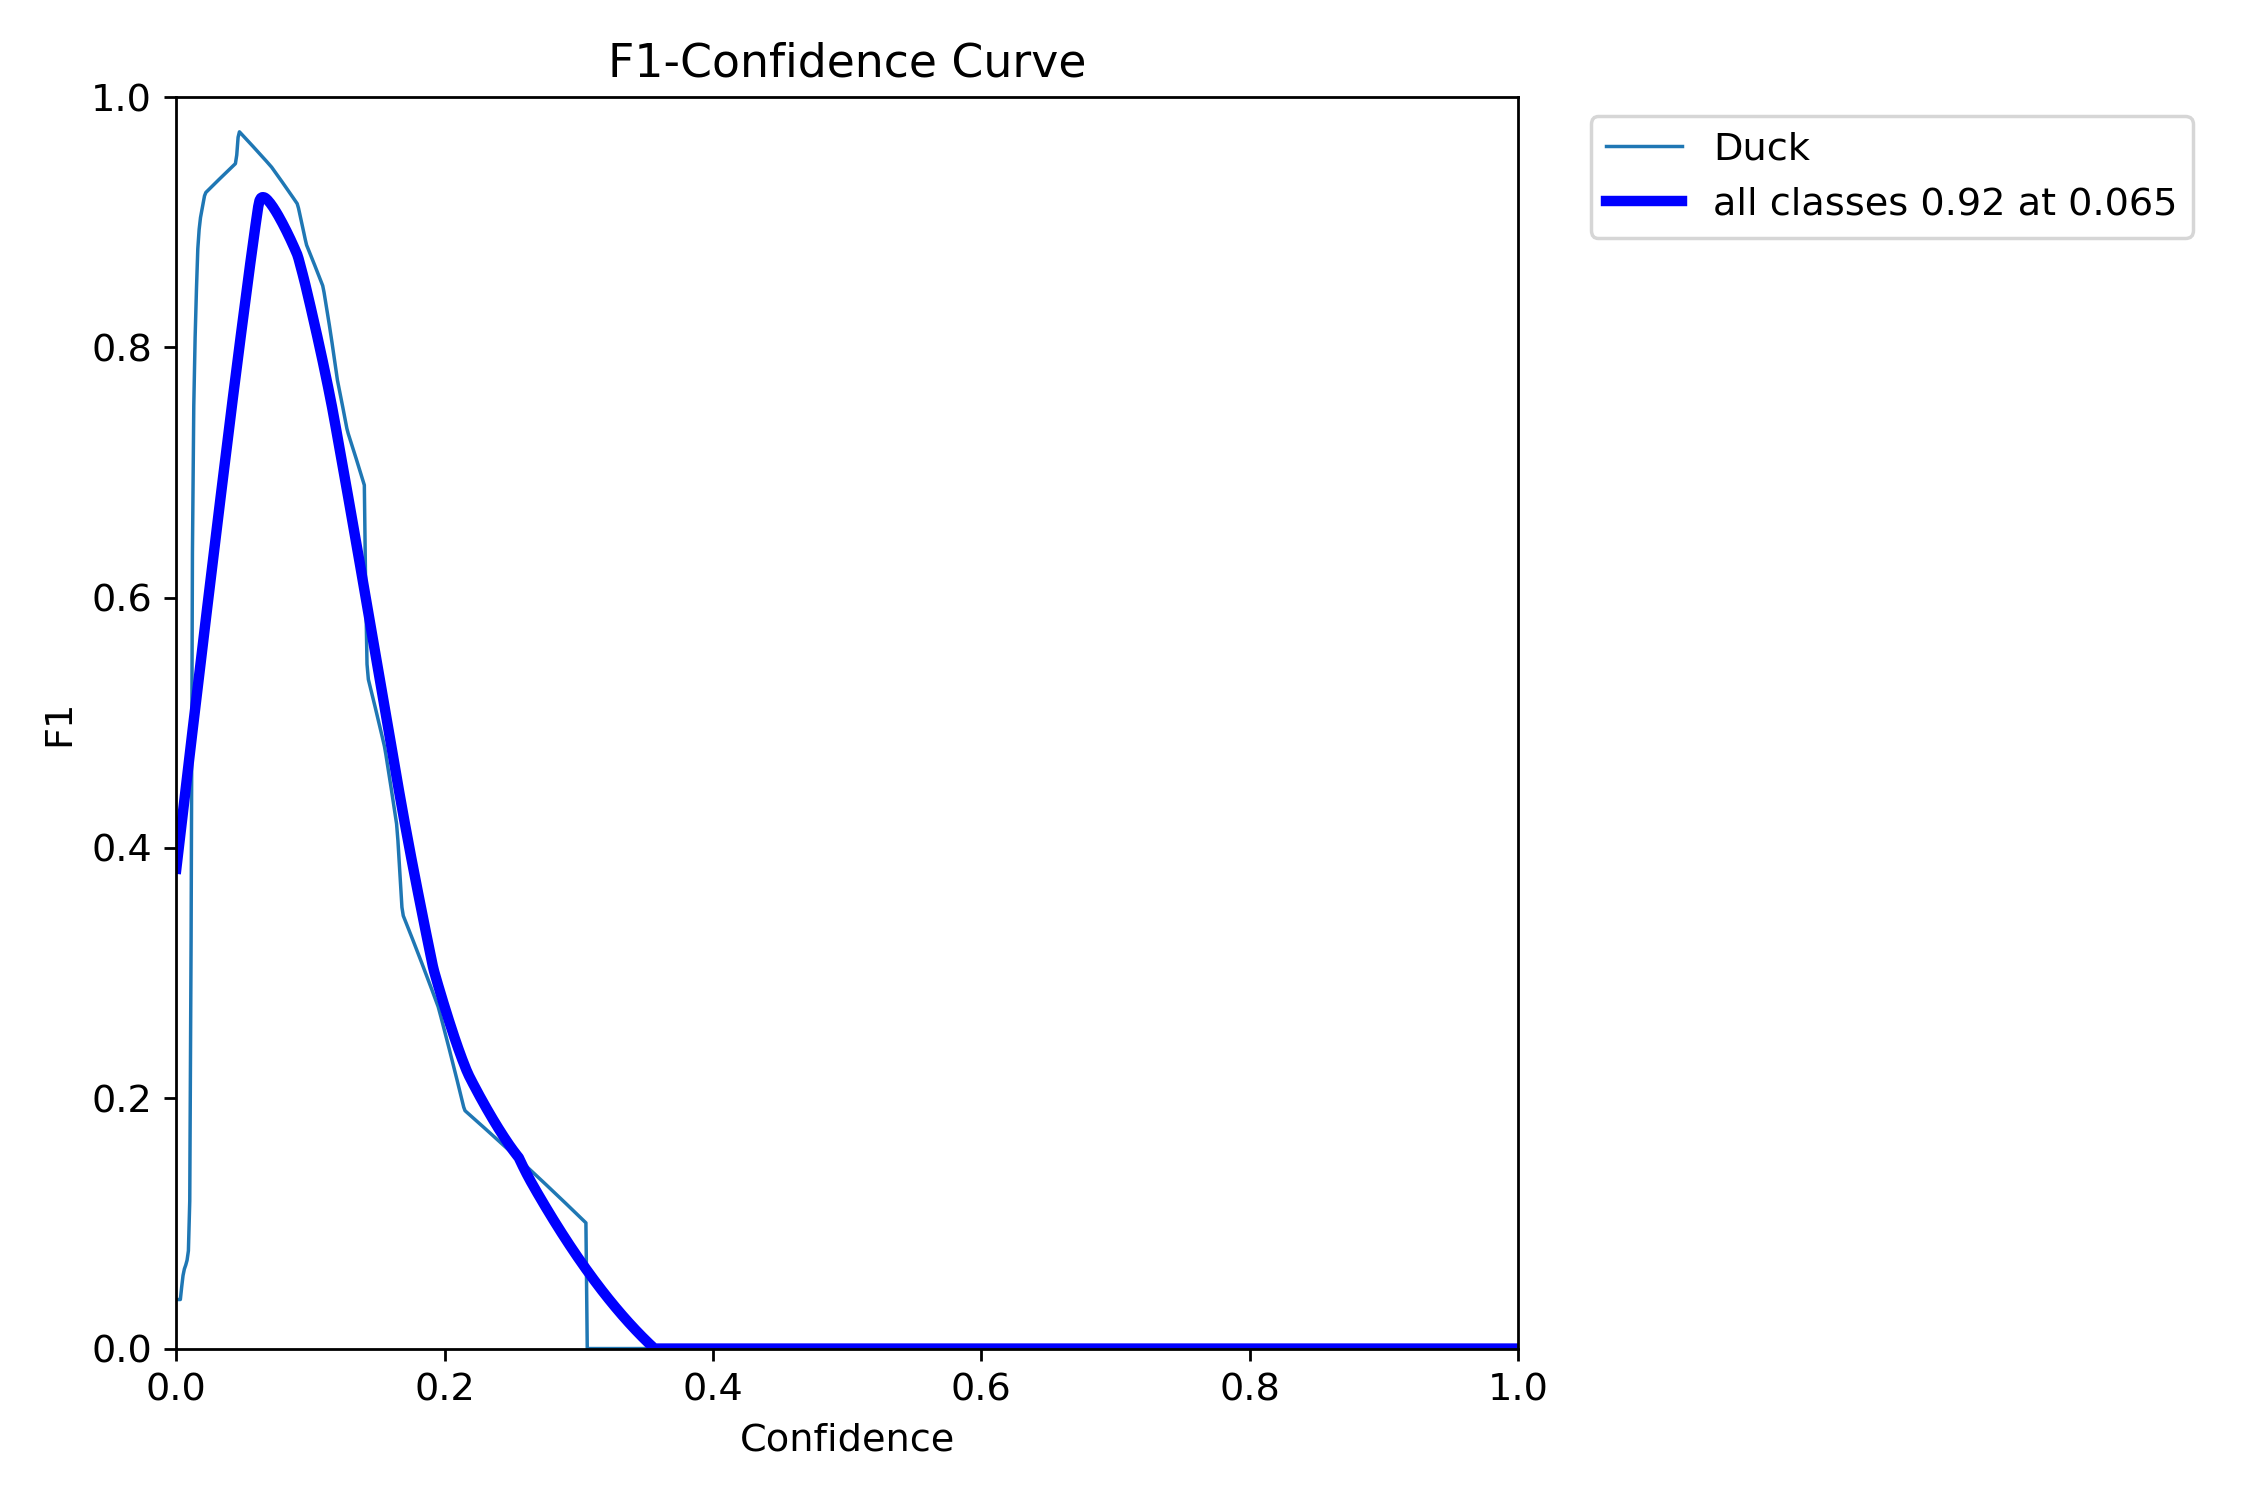

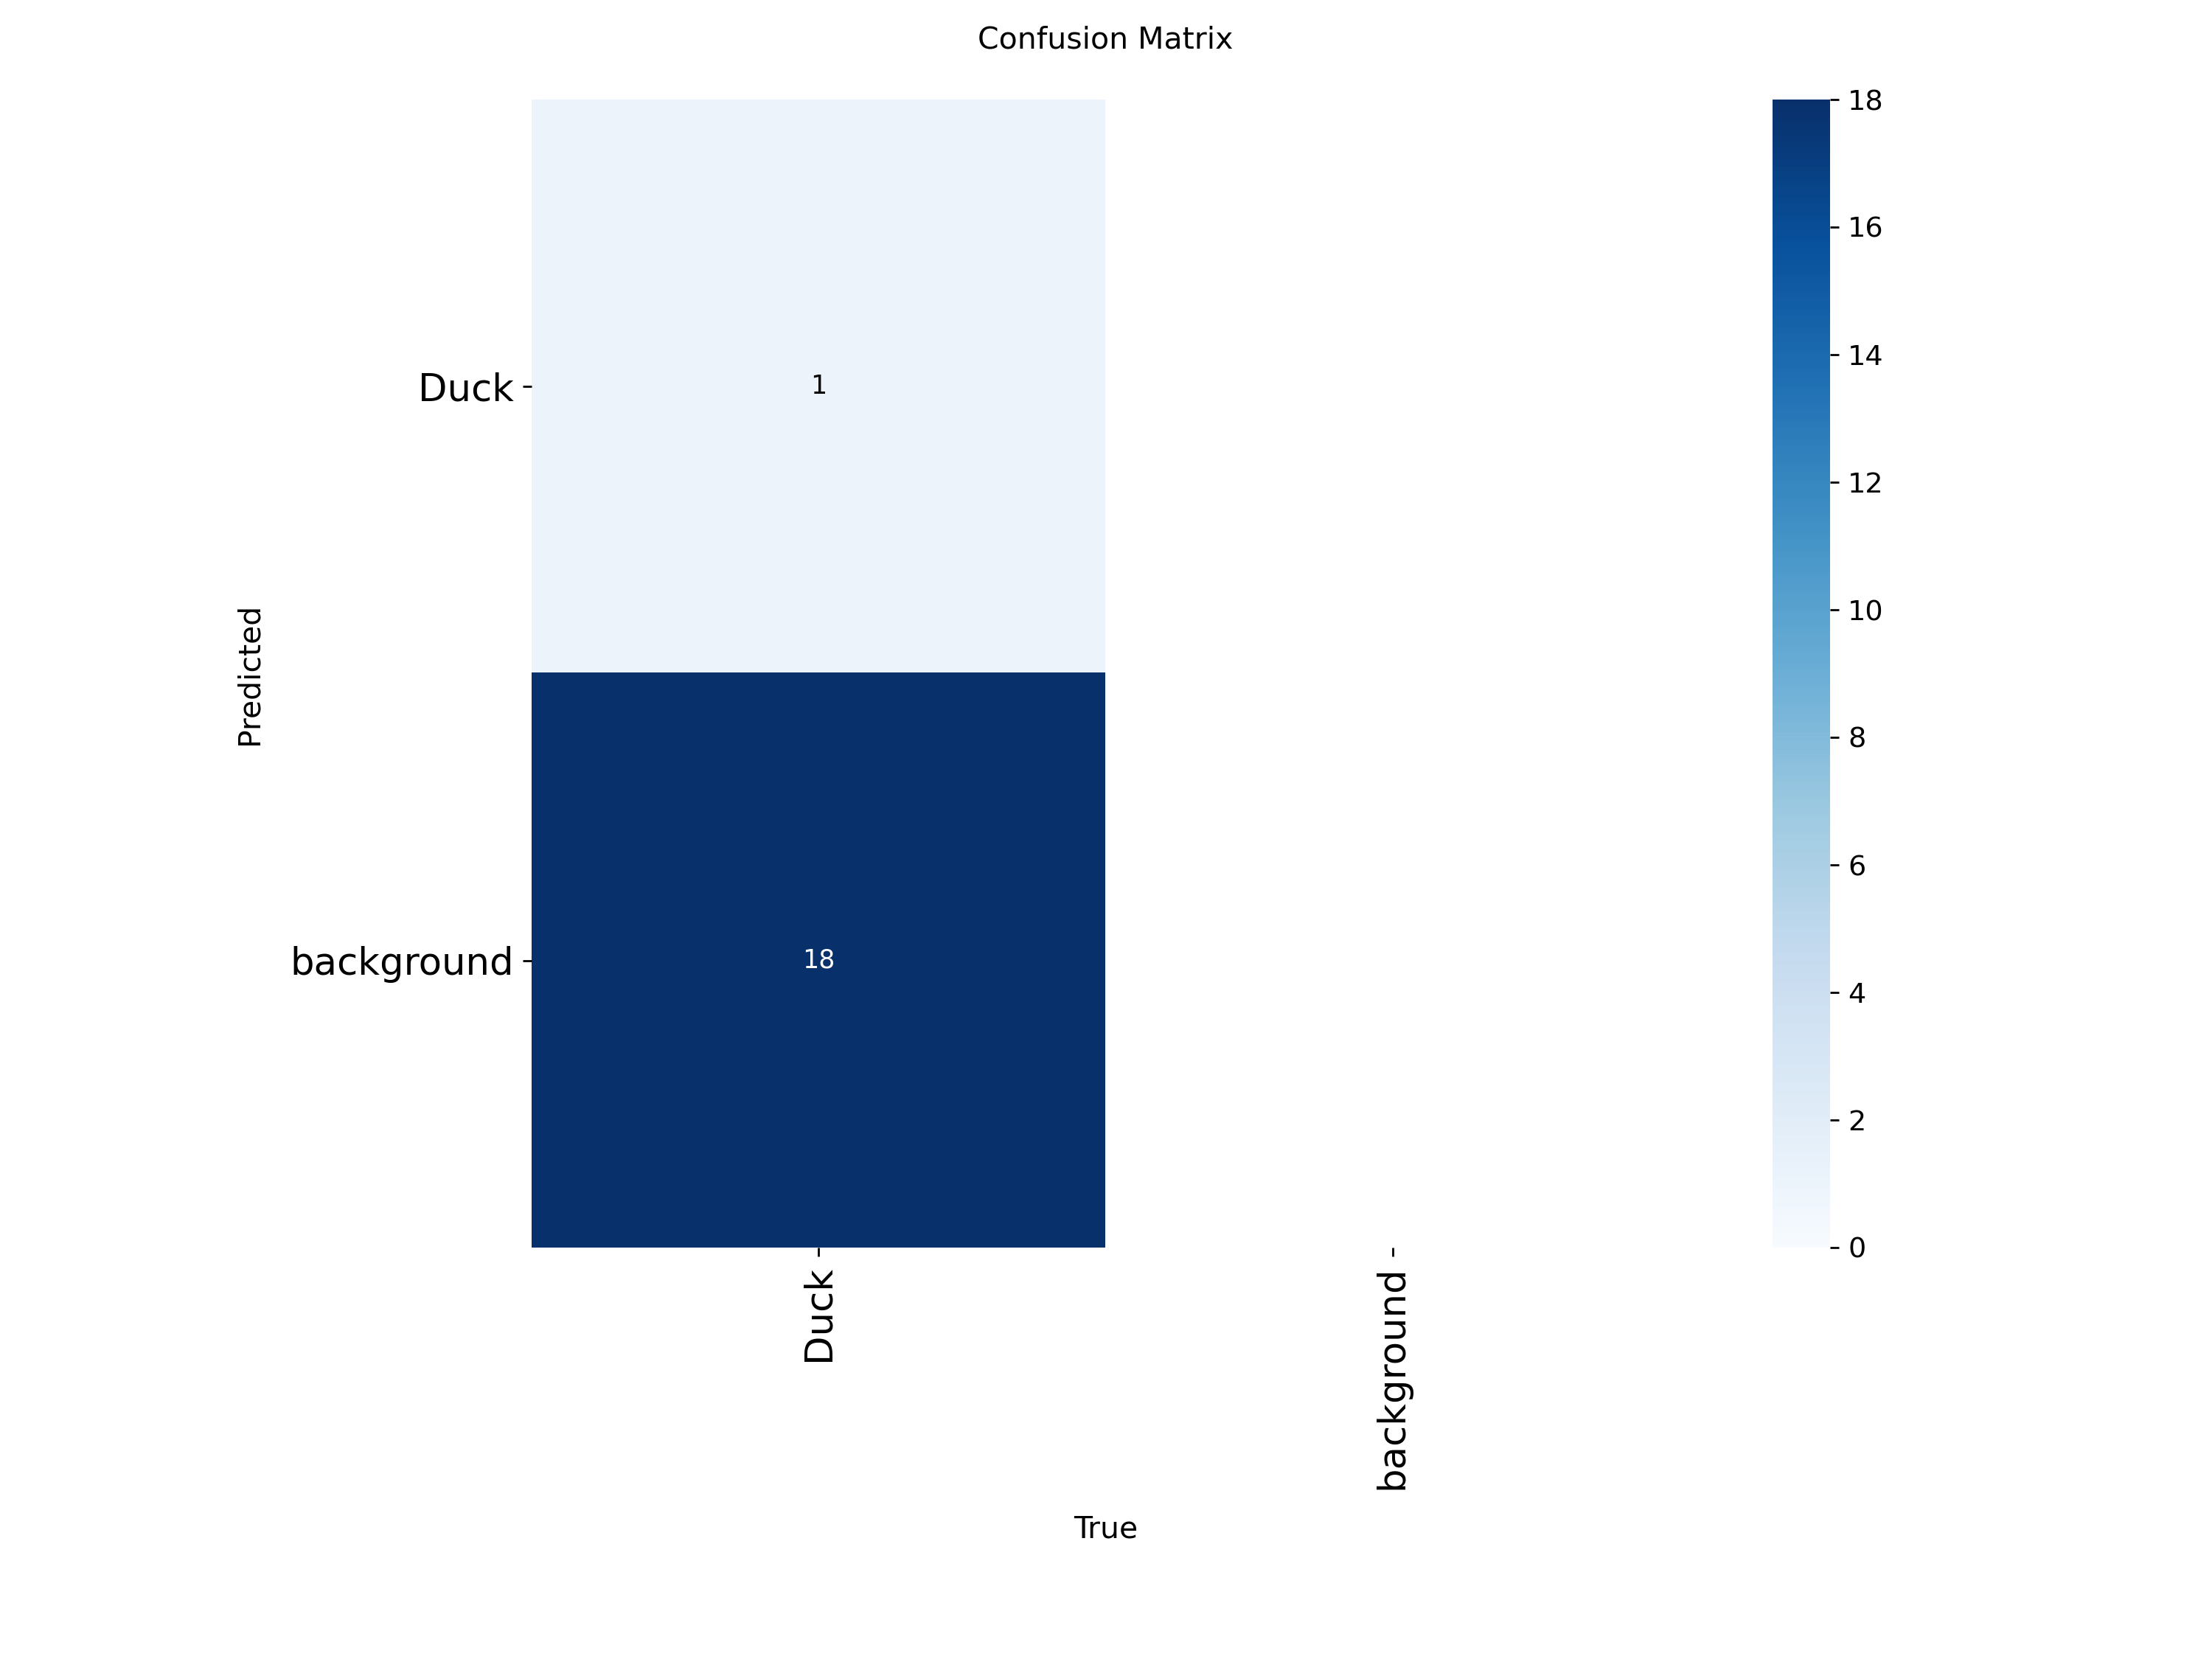

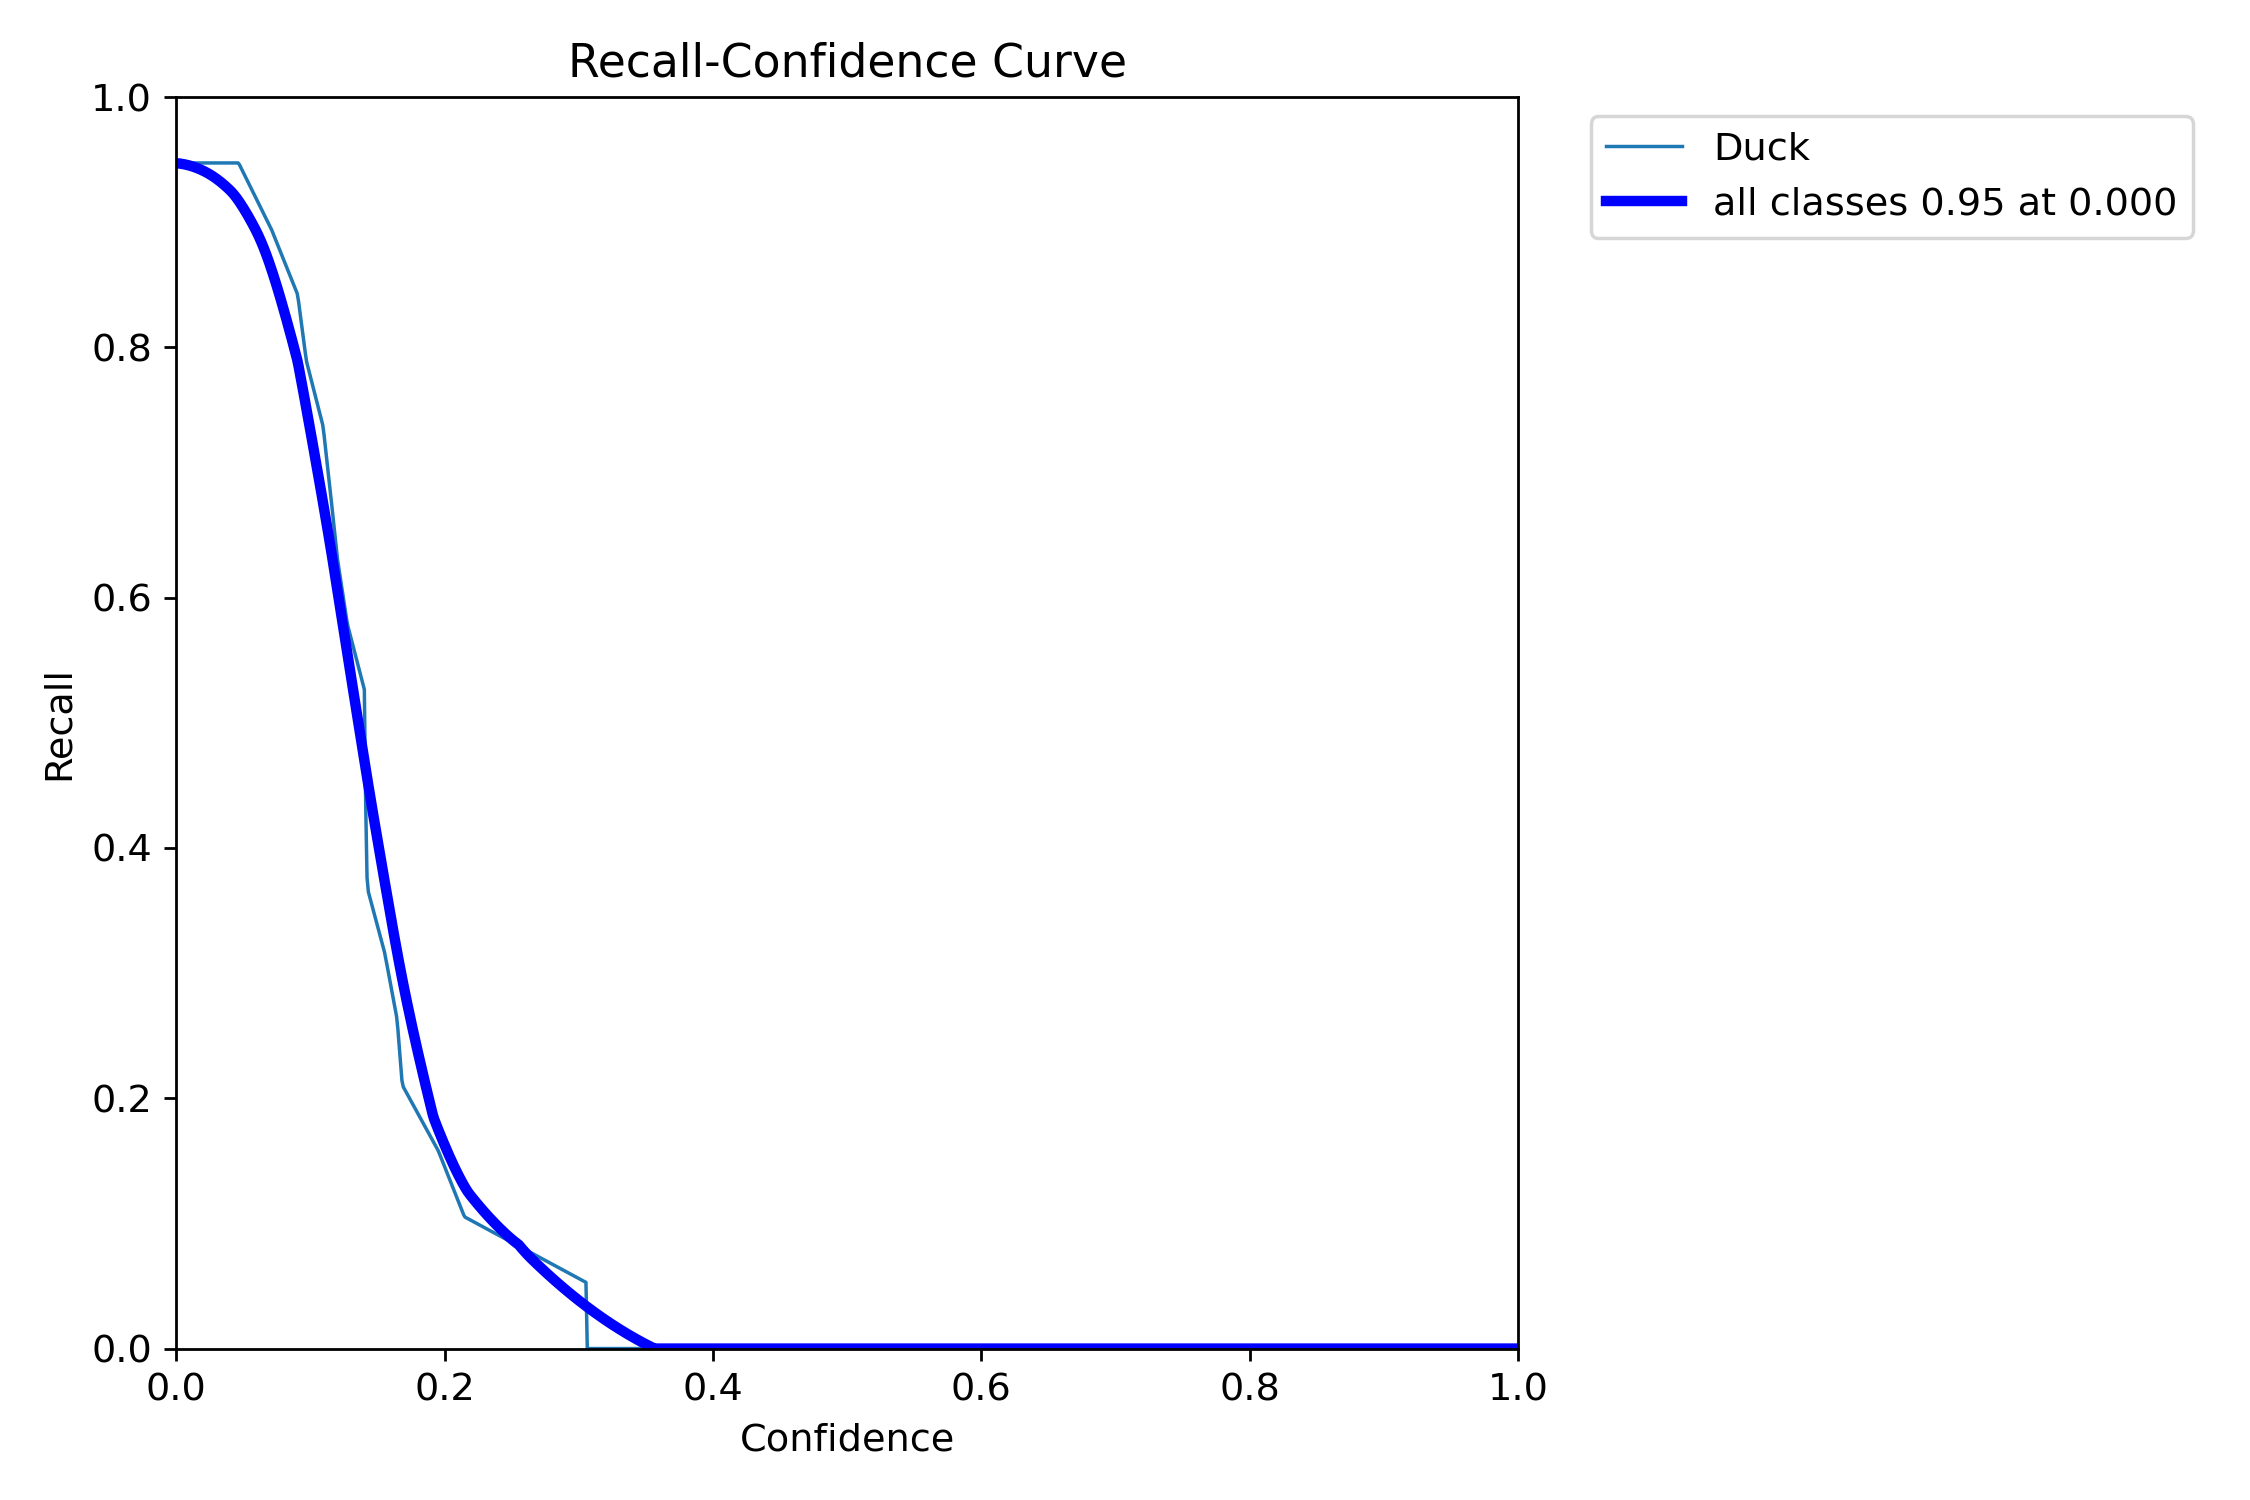

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/val/*.jpg') + glob.glob('/content/runs/detect/val/*.png'):
    display(Image(filename=image_path))

# Save model weight to a folder on Google Drive

In [ ]:
import shutil
import os

drive_path = '/content/drive/MyDrive/Duck detection'

source_dirs = [
    '/content/runs/detect/train',
    '/content/runs/detect/val',
    '/content/runs/detect/predict'
]

for source_dir in source_dirs:
    destination_dir = os.path.join(drive_path, os.path.basename(source_dir))
    if os.path.exists(destination_dir):
        print(f"Removing existing directory: {destination_dir}")
        shutil.rmtree(destination_dir)

    print(f"Copying {source_dir} to {destination_dir}")
    shutil.copytree(source_dir, destination_dir)
    print(f"Copied {source_dir} successfully.")

print("All results copied to Google Drive successfully!")

Removing existing directory: /content/drive/MyDrive/Duck detection/train
Copying /content/runs/detect/train to /content/drive/MyDrive/Duck detection/train
Copied /content/runs/detect/train successfully.
Removing existing directory: /content/drive/MyDrive/Duck detection/val
Copying /content/runs/detect/val to /content/drive/MyDrive/Duck detection/val
Copied /content/runs/detect/val successfully.
Removing existing directory: /content/drive/MyDrive/Duck detection/predict
Copying /content/runs/detect/predict to /content/drive/MyDrive/Duck detection/predict
Copied /content/runs/detect/predict successfully.
All results copied to Google Drive successfully!
